# Were the decisions real?

Notebooks 05 and 06 made a series of keep-or-drop calls: features added, a target changed, weighting introduced, tuning left off. Several of them rested on differences of a few thousandths of Spearman, while the same metric swings by about 0.04 from one cutoff to the next. On that comparison alone, most of the calls look like noise.

That comparison is the wrong one, though. A hard year is hard for every configuration, so two models' scores rise and fall together across cutoffs. What matters is the **per-cutoff difference** between the two, which cancels those shared swings and is far steadier than either score. This notebook re-tests every decision that way.

Two details keep it honest:

- **Paired.** Each comparison uses the difference at each cutoff, not two separate averages.
- **Block bootstrap.** Cutoffs six months apart share most of their training data, and 12-month outcome windows overlap, so the cutoffs are not independent trials. Resampling runs of three consecutive cutoffs, instead of single ones, keeps that dependence and gives wider, more honest intervals than pretending each cutoff is a fresh experiment.

A decision **holds up** when the 95% interval for the improvement excludes zero in its favour. Every comparison reuses exactly the backtest arguments of the notebook that originally made the call, so the numbers are the same numbers.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.analysis import paired_backtest_comparison
from src.modeling import (
    BASE_NUMERIC_FEATURES,
    CLUB_STANDING_FEATURES,
    MARKET_FEATURES,
    ROLE_FEATURES,
    TARGET_CLIP,
    TREND_STEP_FEATURES,
    VALUE_TREND_FEATURES,
    default_backtest_cutoffs,
    enable_backtest_cache,
    walk_forward_backtest,
)
from src.panel import build_snapshot_panel

# Most of these backtests were already run by notebooks 05 and 06 and are served from
# the cache, because each call below repeats their arguments exactly.
enable_backtest_cache()

sns.set_theme(style="whitegrid", context="talk")
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#888888"

panel = build_snapshot_panel()
cutoffs_by_horizon = {months: default_backtest_cutoffs(panel, months=months) for months in (12, 3)}
print({months: len(c) for months, c in cutoffs_by_horizon.items()}, "cutoffs per horizon")

{12: 17, 3: 11} cutoffs per horizon


## Every decision, re-tested

Each row names a decision, whether it was kept at the time, the model and horizon it is judged on, and the two backtest configurations being compared. The baseline is the state before the change; the candidate is the state after it.

In [2]:
B, VT, ROLE, CLUB, STEP, MARKET = (
    BASE_NUMERIC_FEATURES, VALUE_TREND_FEATURES, ROLE_FEATURES,
    CLUB_STANDING_FEATURES, TREND_STEP_FEATURES, MARKET_FEATURES,
)
DEFAULT = B + VT + CLUB
ABLATION = ("ridge", "lasso", "xgboost")    # notebook 05's feature ablation
TWO = ("ridge", "xgboost")                  # notebook 06's market and recency sections
SIZING = ("xgboost", "xgboost_huber")       # notebook 05's target sizing section

decisions = [
    # (decision, verdict at the time, model, months, baseline kwargs, candidate kwargs)
    ("value-trend features", "kept", "xgboost", 12, dict(model_names=ABLATION, numeric_features=B), dict(model_names=ABLATION, numeric_features=B + VT)),
    ("value-trend features", "kept", "xgboost", 3, dict(model_names=ABLATION, numeric_features=B), dict(model_names=ABLATION, numeric_features=B + VT)),
    ("log-ratio target", "kept", "xgboost", 12, dict(model_names=SIZING, target_transform="pct", clip=TARGET_CLIP), dict(model_names=SIZING, target_transform="log_ratio", clip=TARGET_CLIP)),
    ("club-standing features", "kept", "xgboost", 12, dict(model_names=ABLATION, numeric_features=B + VT), dict(model_names=ABLATION, numeric_features=DEFAULT)),
    ("club-standing features", "kept", "xgboost", 3, dict(model_names=ABLATION, numeric_features=B + VT), dict(model_names=ABLATION, numeric_features=DEFAULT)),
    ("recency weighting (4-year)", "kept", "xgboost", 12, dict(model_names=TWO, recency_half_life_years=None), dict(model_names=TWO, recency_half_life_years=4.0)),
    ("recency weighting (4-year)", "kept", "xgboost", 3, dict(model_names=TWO, recency_half_life_years=None), dict(model_names=TWO, recency_half_life_years=4.0)),
    ("role & discipline features", "dropped", "xgboost", 12, dict(model_names=ABLATION, numeric_features=B), dict(model_names=ABLATION, numeric_features=B + ROLE)),
    ("market-drift feature", "dropped", "xgboost", 12, dict(model_names=TWO, numeric_features=DEFAULT), dict(model_names=TWO, numeric_features=DEFAULT + MARKET)),
    ("step flags", "dropped", "xgboost", 12, dict(model_names=ABLATION, numeric_features=DEFAULT), dict(model_names=ABLATION, numeric_features=DEFAULT + STEP)),
    ("step flags", "dropped", "lasso", 12, dict(model_names=ABLATION, numeric_features=DEFAULT), dict(model_names=ABLATION, numeric_features=DEFAULT + STEP)),
    ("step flags", "dropped", "lasso", 3, dict(model_names=ABLATION, numeric_features=DEFAULT), dict(model_names=ABLATION, numeric_features=DEFAULT + STEP)),
    ("hyper-parameter tuning", "dropped", "xgboost", 12, dict(model_names=ABLATION), dict(model_names=ABLATION, tune=True)),
]


def backtest_metrics(months: int, model: str, kwargs: dict) -> pd.DataFrame:
    metrics, _ = walk_forward_backtest(panel, months=months, cutoffs=cutoffs_by_horizon[months], **kwargs)
    return metrics[metrics["model"] == model]


rows = []
for decision, verdict, model, months, base_kwargs, cand_kwargs in decisions:
    base = backtest_metrics(months, model, base_kwargs)
    cand = backtest_metrics(months, model, cand_kwargs)
    spearman = paired_backtest_comparison(base, cand, metric="spearman")
    mae = paired_backtest_comparison(base, cand, metric="mae", higher_is_better=False)
    rows.append({
        "decision": decision, "at the time": verdict, "model": model, "horizon": f"{months}m",
        "spearman gain": spearman["mean_improvement"],
        "spearman 95% low": spearman["ci_low"], "spearman 95% high": spearman["ci_high"],
        "cutoffs won": f'{spearman["cutoffs_won"]}/{spearman["cutoffs"]}',
        "mae gain": mae["mean_improvement"],
        "mae 95% low": mae["ci_low"], "mae 95% high": mae["ci_high"],
    })
results = pd.DataFrame(rows)


def verdict(low: float, high: float) -> str:
    if low > 0:
        return "better"
    if high < 0:
        return "worse"
    return "can't tell"


results["spearman says"] = [verdict(lo, hi) for lo, hi in zip(results["spearman 95% low"], results["spearman 95% high"])]
results["mae says"] = [verdict(lo, hi) for lo, hi in zip(results["mae 95% low"], results["mae 95% high"])]
display(results.round(4))

,decision,at the time,model,horizon,spearman gain,spearman 95% low,spearman 95% high,cutoffs won,mae gain,mae 95% low,mae 95% high,spearman says,mae says
0,value-trend features,kept,xgboost,12m,0.0325,0.0238,0.0445,15/17,0.0129,0.0103,0.0172,better,better
1,value-trend features,kept,xgboost,3m,0.0826,0.0629,0.0925,11/11,0.0108,0.0072,0.0145,better,better
2,log-ratio target,kept,xgboost,12m,0.0211,0.0173,0.0248,17/17,0.0545,0.0426,0.0673,better,better
3,club-standing features,kept,xgboost,12m,0.0049,0.0029,0.0085,12/17,0.0043,0.0025,0.0062,better,better
4,club-standing features,kept,xgboost,3m,0.0005,-0.0094,0.0121,7/11,0.0016,-0.0008,0.0048,can't tell,can't tell
5,recency weighting (4-year),kept,xgboost,12m,0.0030,-0.0007,0.0068,12/17,0.0047,0.0031,0.0059,can't tell,better
6,recency weighting (4-year),kept,xgboost,3m,0.0239,0.0148,0.0390,10/11,0.0103,0.0059,0.0179,better,better
7,role & discipline features,dropped,xgboost,12m,0.0013,-0.0011,0.0040,9/17,0.0006,-0.0001,0.0012,can't tell,can't tell
8,market-drift feature,dropped,xgboost,12m,0.0008,-0.0018,0.0038,9/17,0.0005,-0.0039,0.0041,can't tell,can't tell
9,step flags,dropped,xgboost,12m,-0.0014,-0.0046,0.0003,5/17,-0.0005,-0.0019,0.0004,can't tell,can't tell


## The same result as a picture

Each bar is the 95% interval for the change in rank accuracy that a decision caused, with the dot at its average. Anything whose bar stays clear of the zero line is a real effect in that direction; anything that straddles it could be noise.

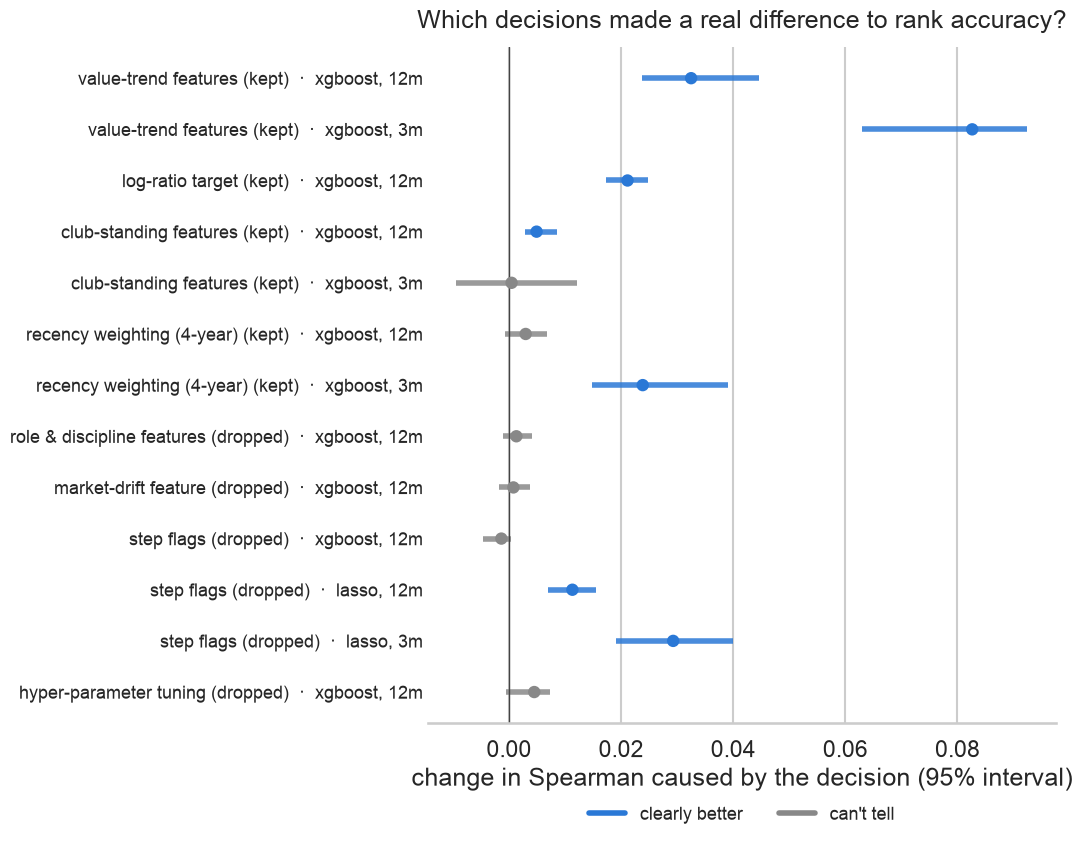

In [3]:
plot = results.iloc[::-1].reset_index(drop=True)
labels = [f"{r['decision']} ({r['at the time']})  ·  {r['model']}, {r['horizon']}" for _, r in plot.iterrows()]
colors = [BLUE if s == "better" else ORANGE if s == "worse" else GREY for s in plot["spearman says"]]

fig, ax = plt.subplots(figsize=(11, 0.55 * len(plot) + 1.6))
y = np.arange(len(plot))
ax.hlines(y, plot["spearman 95% low"], plot["spearman 95% high"], color=colors, linewidth=4, alpha=0.85)
ax.scatter(plot["spearman gain"], y, color=colors, s=55, zorder=3)
ax.axvline(0, color="#444444", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=13)
ax.set_xlabel("change in Spearman caused by the decision (95% interval)")
ax.set_title("Which decisions made a real difference to rank accuracy?", pad=14)
present = [(c, name) for c, name, key in ((BLUE, "clearly better", "better"), (GREY, "can't tell", "can't tell"), (ORANGE, "clearly worse", "worse"))
           if key in set(plot["spearman says"])]
ax.legend([plt.Line2D([], [], color=c, linewidth=4) for c, _ in present], [name for _, name in present],
          frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=len(present), fontsize=13)
sns.despine(ax=ax, left=True)
ax.tick_params(axis="y", length=0)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Every decision survives, and the test was sharp enough to have caught a mistake if there was one.

**The three big changes are unmistakable.** The value-trend features improved ranking at both horizons, winning 15 of 17 cutoffs at 12 months and all 11 at 3 months. Switching the target to a log ratio improved ranking at *every one* of the 17 cutoffs and cut error sharply.

**Club standing is small but real, and only at 12 months.** Its gain of half a hundredth of Spearman is about an eighth of the metric's spread across cutoffs, which is why it looked like noise, yet the paired interval stays clear of zero, it won 12 of 17 cutoffs, and error falls too. At 3 months it does nothing, as notebook 05 already reported. The features earn their place for the 12-month forecast and are simply along for the ride at 3.

**Recency weighting is justified, but not by the 12-month ranking.** At 3 months the gain is clear (10 of 11 cutoffs). At 12 months the ranking improvement is not established: its interval touches zero. What *is* established at 12 months is lower error, won at 16 of 17 cutoffs, and that, along with the post-2019 bias it was introduced to reduce, is the honest case for it at that horizon. Notebook 06 section 2 should be read that way.

**Nothing dropped was a real improvement left on the table for the default model.** Role and discipline features, the market-drift feature, the step flags for XGBoost and hyper-parameter tuning all come out as "can't tell". The step flags *for lasso* are clearly real at both horizons, which turns notebook 06's step reading from a pattern in a partial-dependence plot into a tested result.

## Does the answer depend on the block length?

Three consecutive cutoffs per block is a judgment call. A block of one treats every cutoff as an independent trial, which is too optimistic here. Longer blocks keep more of the dependence between neighbouring cutoffs, but with only 17 cutoffs they also leave few distinct ways to resample, so they are not automatically more cautious. If a verdict flips between block lengths, it is fragile and should be read that way.

In [4]:
sensitivity = []
for decision, verdict_then, model, months, base_kwargs, cand_kwargs in decisions:
    base = backtest_metrics(months, model, base_kwargs)
    cand = backtest_metrics(months, model, cand_kwargs)
    row = {"decision": decision, "model": model, "horizon": f"{months}m"}
    for block in (1, 3, 5):
        r = paired_backtest_comparison(base, cand, metric="spearman", block_length=block)
        row[f"block {block}"] = verdict(r["ci_low"], r["ci_high"])
    sensitivity.append(row)
sensitivity = pd.DataFrame(sensitivity)
sensitivity["stable"] = sensitivity[["block 1", "block 3", "block 5"]].nunique(axis=1) == 1
display(sensitivity)

,decision,model,horizon,block 1,block 3,block 5,stable
0,value-trend features,xgboost,12m,better,better,better,True
1,value-trend features,xgboost,3m,better,better,better,True
2,log-ratio target,xgboost,12m,better,better,better,True
3,club-standing features,xgboost,12m,better,better,better,True
4,club-standing features,xgboost,3m,can't tell,can't tell,can't tell,True
5,recency weighting (4-year),xgboost,12m,better,can't tell,can't tell,False
6,recency weighting (4-year),xgboost,3m,better,better,better,True
7,role & discipline features,xgboost,12m,can't tell,can't tell,can't tell,True
8,market-drift feature,xgboost,12m,can't tell,can't tell,can't tell,True
9,step flags,xgboost,12m,can't tell,can't tell,worse,False


Ten of thirteen verdicts are identical at every block length. The other three flip, and in each case the flip is a knife edge rather than a change of substance: one end of the interval moves from just above zero to just below it, by less than a thousandth, while the interval's width barely changes. None of them changes a decision.

- **Recency weighting at 12 months** and **tuning** count as "better" only when every cutoff is treated as independent, the optimistic assumption this notebook exists to avoid. Neither should be counted as a ranking gain. Tuning stays off, and recency's 12-month case rests on error, which is clearly better at all three block lengths.
- **Step flags for XGBoost** tip into "worse" at a block of five, with the top of the interval a hair below zero. At most that says the flags slightly hurt the default model, which is why they were already left out.

## What this changes

Nothing in the default model, and one sentence in how it should be described. The headline decisions were real rather than tuned to noise, and the thing that looked most like noise, a 0.005 gain from club standing, turned out to be one of the steadier results once measured properly. The honest correction is to recency weighting: it is kept for its effect on error and on the 3-month forecast, not because it improves 12-month ranking.